# EDA: Heart Failure Prediction
Dataset: UCI Heart Failure Clinical Records (299 patient, 13 columns) <br>
Objective: Predicting death patients with heart failure within follow up period (DEATH_EVENT)

## Data Overview
The dataset contains 13 clinical features: 12 predictor features (age, blood pressure, lab results, medical history) and one binary target, DEATH_EVENT (1 = death, 0 = survived). All columns are already numeric, making them ready for use in models without additional encoding.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Ameng\Data Science Project\heart-failure-prediction\data\heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Data Quality

In [16]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Missing values: 0
Duplicates: 0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


All of the column has 299 non-null values, no missing values. No duplicate data. Float64 data type for continous features and int64 for binary features. No cleaning process needed

## Descriptive Analysis

In [4]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


- Age range between 40-95 years, mean ~65 years: elderly population
- `serum_creatinine` (max 9.4 vs median 1.1) and `creatinine_phosphokinase` (max 7.861 vs median 250) highly right-skewed
- `time` around 4-285 days: The duration of follow-up varies
- The scales of the features differ significantly (`platelets` in the hundreds of thousands vs. `ejection_fraction` of 14–80) → standardization is required for distance-based models

## Target Variable Analysis

In [5]:
print("Target distribution:")
print(df['DEATH_EVENT'].value_counts())
print("\nTarget percentage:")
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100)

Target distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Target percentage:
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


C:\Users\akmal\AppData\Local\Temp\ipykernel_8012\2105461242.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Survived (0)", "Dead (1)"])


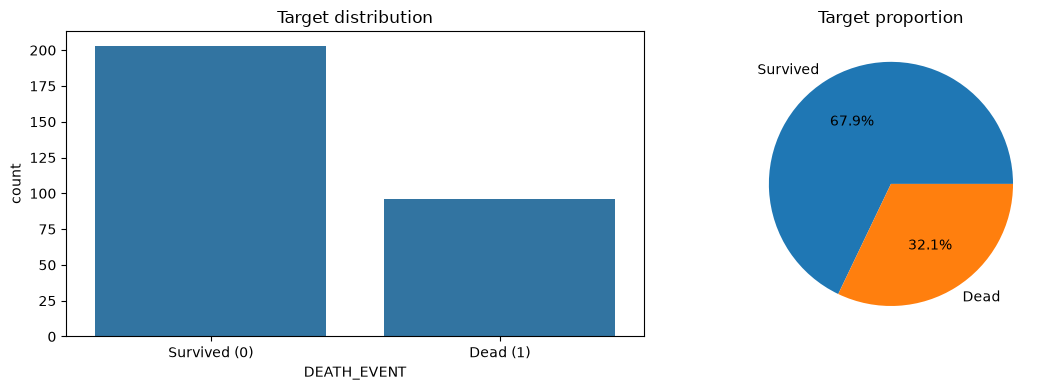

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df, x="DEATH_EVENT", ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xticklabels(["Survived (0)", "Dead (1)"])

df["DEATH_EVENT"].value_counts().plot(kind="pie",
                                    labels=["Survived", "Dead"],
                                    autopct="%1.1f%%",
                                    ax=axes[1])
axes[1].set_title("Target proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Imbalanced target distribution: 67.89% survived vs. 32.11% died (ratio ~2:1).
Implications:
1. Accuracy is not the primary metric: use Precision, Recall, F1, AUC-ROC.
2. Use `stratify=y` during the train-test split.
3. Consider `class_weight='balanced'` for the model.

## Feature Distribution

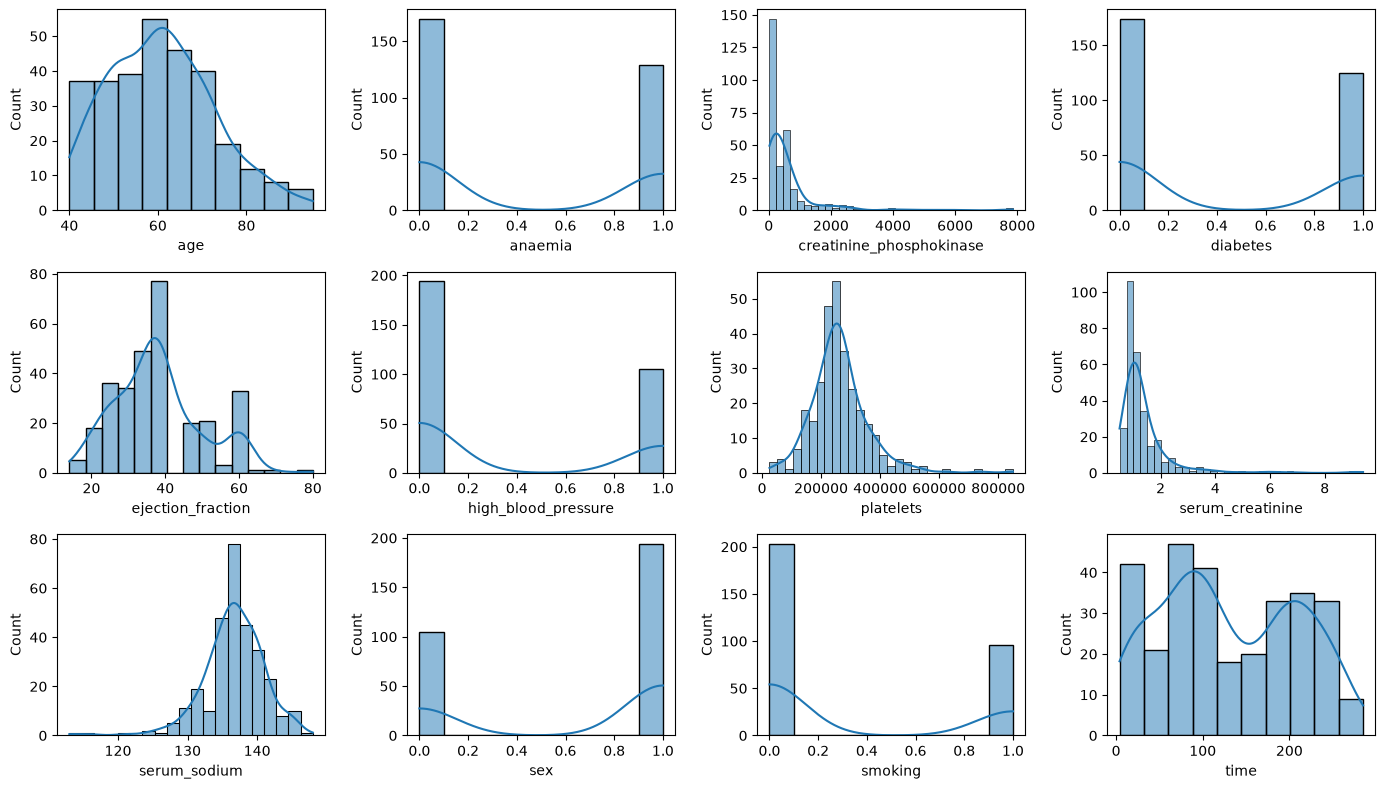

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()
i = 0
for column in df:
    if column != "DEATH_EVENT":
        sns.histplot(df[column], kde=True, ax=axes[i])
        axes[i].set_xlabel(column)
        i += 1

plt.tight_layout()
plt.show()

The features are divided into three groups: 
1. continuous and approximately normal: `age`, `serum_sodium`, `ejection_fraction`
2. continuous and right-skewed with outliers: `creatinine_phosphokinase`, `serum_creatinine`, `platelets`, `time` (require log-transformation/scaling)
3. binary: `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking` (analyze using proportion charts, not boxplots).

In [8]:
corr = df.corr()["DEATH_EVENT"].sort_values(key=abs, ascending=False)
print(corr.drop("DEATH_EVENT"))

time                       -0.526964
serum_creatinine            0.294278
ejection_fraction          -0.268603
age                         0.253729
serum_sodium               -0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
platelets                  -0.049139
smoking                    -0.012623
sex                        -0.004316
diabetes                   -0.001943
Name: DEATH_EVENT, dtype: float64


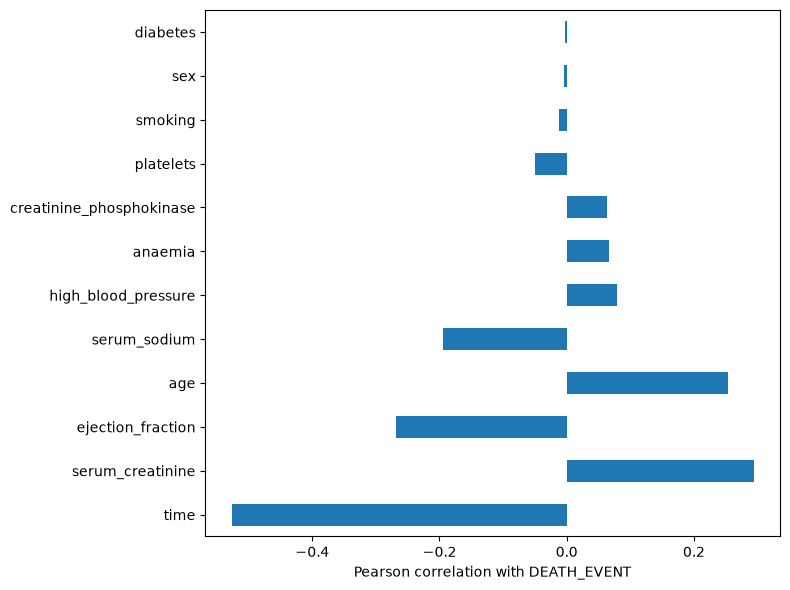

In [9]:
corr = df.corr()["DEATH_EVENT"].sort_values(key=abs, ascending=False)
corr.drop("DEATH_EVENT").plot(kind="barh", figsize=(8, 6))
plt.xlabel("Pearson correlation with DEATH_EVENT")
plt.tight_layout()
plt.show()

- `time`: The longer the follow-up, the lower the likelihood of death during the observation period. Patients who die automatically have a shorter observation period.
- The four strongest clinical predictors: `serum_creatinine`, `ejection_fraction`, `age`, and `serum_sodium`are consistent with the heart failure literature.

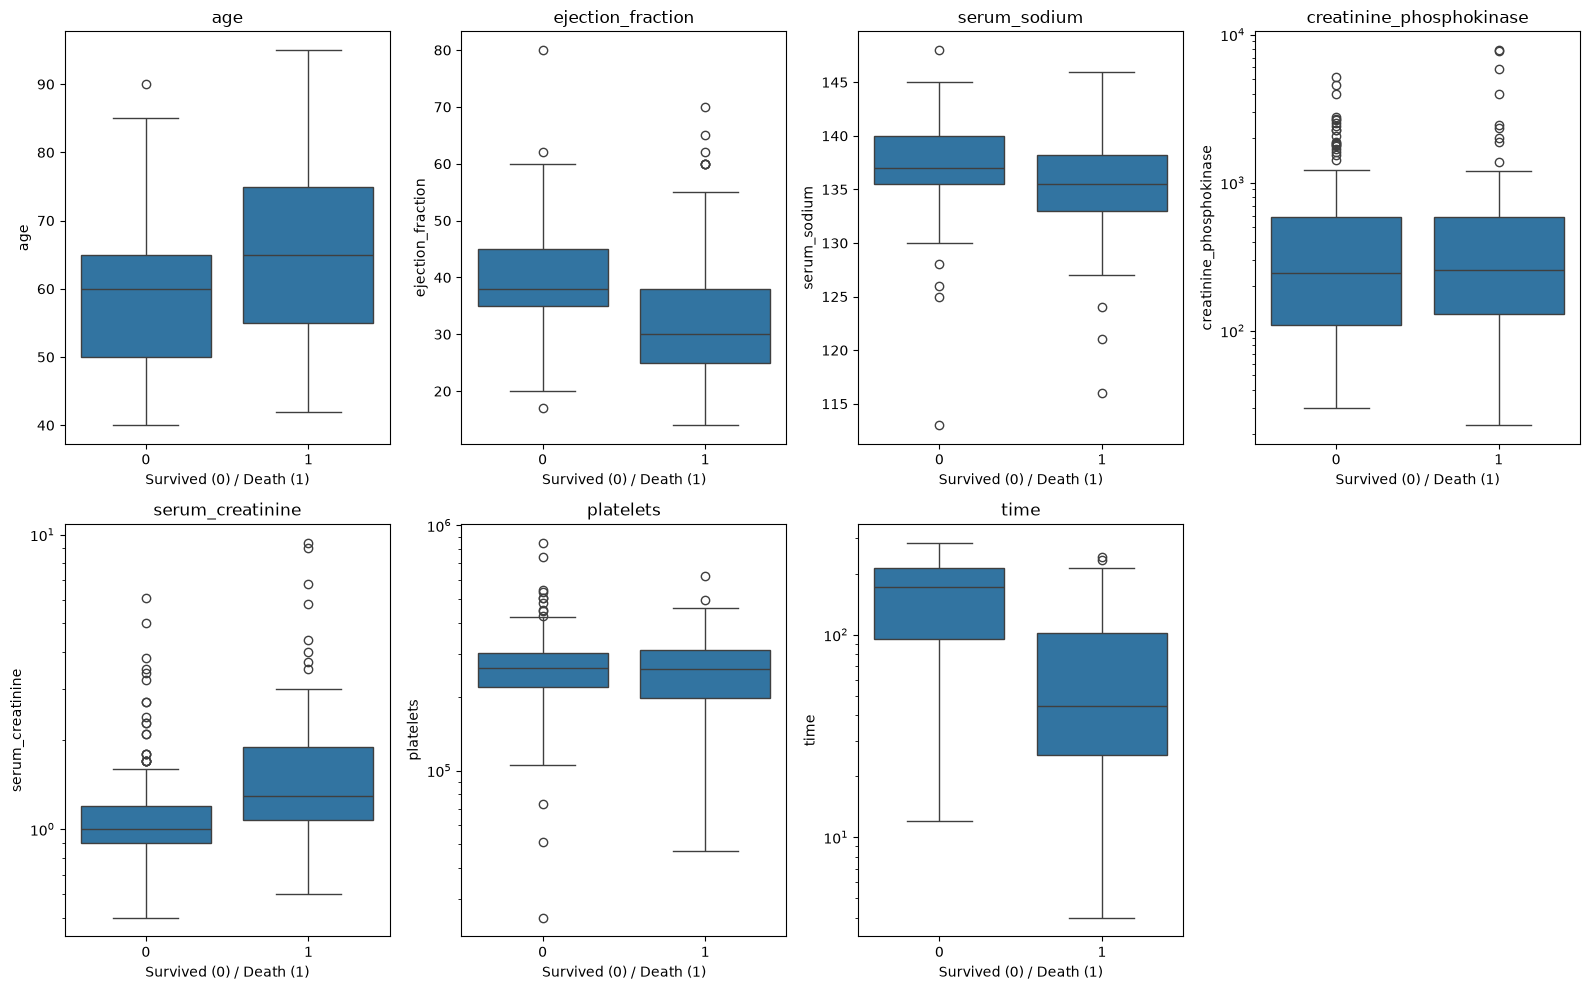

In [10]:
cont_features = ["age", "ejection_fraction", "serum_sodium",
                 "creatinine_phosphokinase", "serum_creatinine",
                 "platelets", "time"]

fig, axes = plt.subplots(2, 4, figsize=(16, 10)) 
axes = axes.flatten()

for i, feature in enumerate(cont_features):
    sns.boxplot(data=df, x="DEATH_EVENT", y=feature, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel("Survived (0) / Death (1)")
    if feature in ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time"]:
        axes[i].set_yscale("log")

axes[-1].axis("off") 
plt.tight_layout()
plt.show()

Boxplots reveal differences in the distributions of several continuous features. The "Death" group (1) tends to exhibit higher age and serum creatinine levels, as well as lower ejection fraction, serum sodium, and time values, compared to the "Survived" group (0). Meanwhile, platelets and creatinine phosphokinase do not show marked differences in distribution.

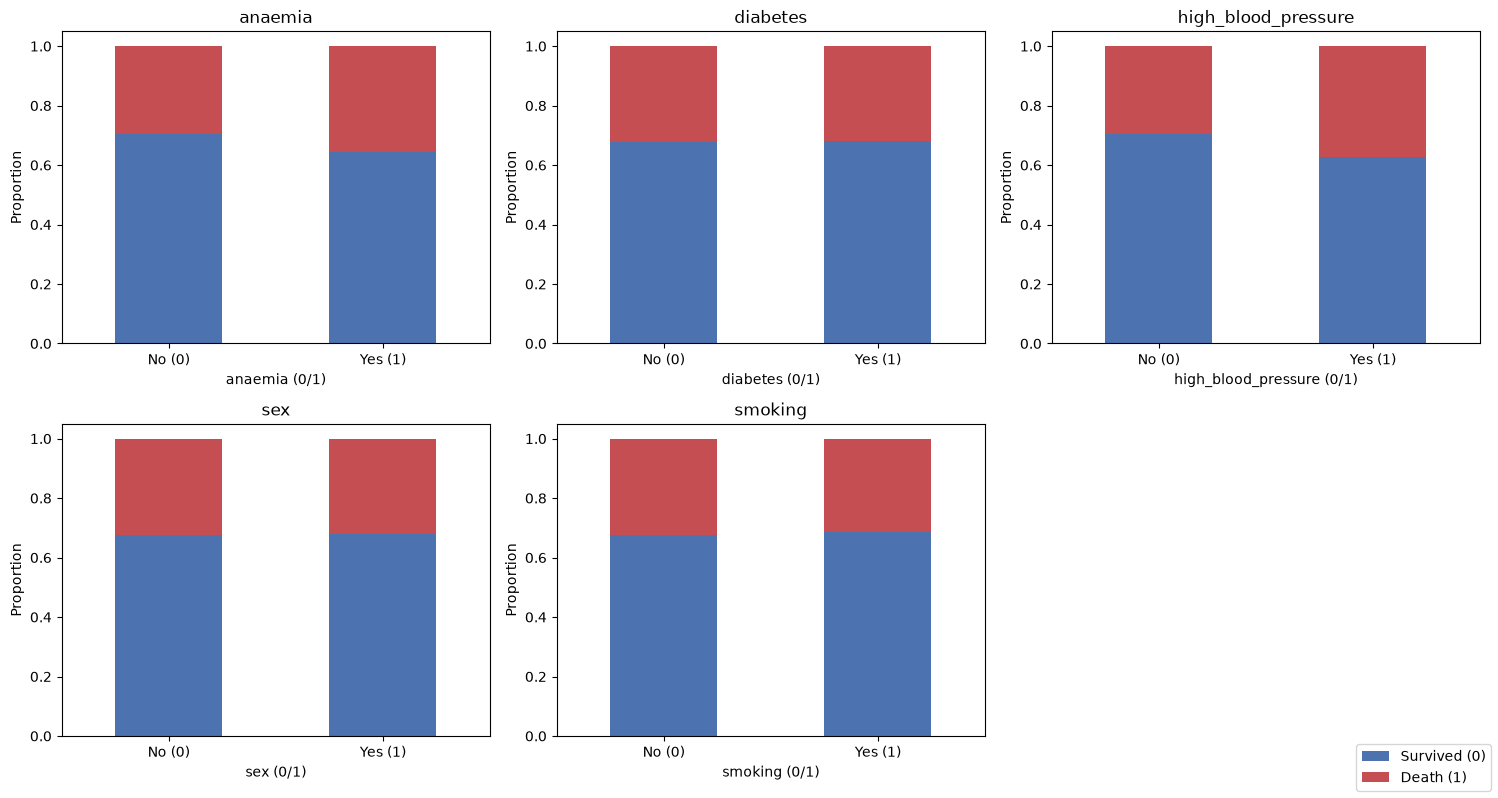

In [11]:
bin_features = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(bin_features):
    pd.crosstab(df[feature], df["DEATH_EVENT"], normalize="index").plot(
        kind="bar", stacked=True, ax=axes[i],
        color=["#4C72B0", "#C44E52"], legend=False)
    axes[i].set_title(feature)
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(f"{feature} (0/1)")
    axes[i].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["Survived (0)", "Death (1)"], loc="lower right")
plt.tight_layout()
plt.show()

Based on the crosstab, high blood pressure and anemia show slightly higher proportions of deaths. Conversely, diabetes, sex, and smoking do not show visually significant differences in proportions.

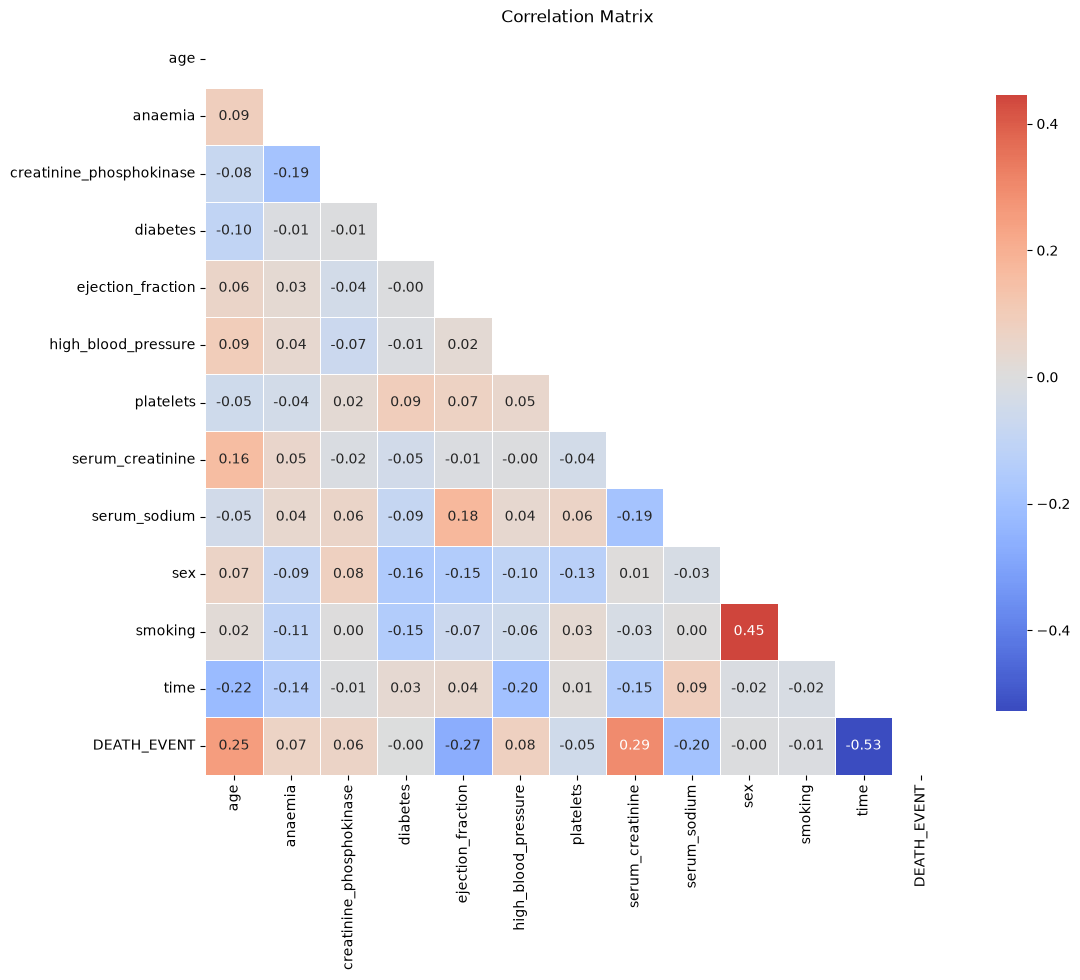

In [14]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            mask=mask,
            cmap='coolwarm',
            annot=True,
            fmt=".2f",
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()